In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report, log_loss
)

In [25]:
df = pd.read_csv("/content/loan_data.csv")

print(df.head())
print(df.info())

   person_age person_gender person_education  person_income  person_emp_exp  \
0        22.0        female           Master        71948.0               0   
1        21.0        female      High School        12282.0               0   
2        25.0        female      High School        12438.0               3   
3        23.0        female         Bachelor        79753.0               0   
4        24.0          male           Master        66135.0               1   

  person_home_ownership  loan_amnt loan_intent  loan_int_rate  \
0                  RENT    35000.0    PERSONAL          16.02   
1                   OWN     1000.0   EDUCATION          11.14   
2              MORTGAGE     5500.0     MEDICAL          12.87   
3                  RENT    35000.0     MEDICAL          15.23   
4                  RENT    35000.0     MEDICAL          14.27   

   loan_percent_income  cb_person_cred_hist_length  credit_score  \
0                 0.49                         3.0           561  

In [26]:
# Fill numeric with median
for col in df.select_dtypes(include=['int64', 'float64']):
    df[col] = df[col].fillna(df[col].median())

# Fill categorical with mode
for col in df.select_dtypes(include=['object']):
    df[col] = df[col].fillna(df[col].mode()[0])

In [27]:
le = LabelEncoder()

for col in df.select_dtypes(include=['object']):
    df[col] = le.fit_transform(df[col])

In [28]:
target_col = 'loan_status'

X = df.drop(target_col, axis=1)
y = df[target_col]

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [30]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [31]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [32]:
y_pred = rf.predict(X_test)

print("\n=== Base Model ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))


=== Base Model ===
Accuracy: 0.9273333333333333
Precision: 0.886986301369863
Recall: 0.7731343283582089
F1 Score: 0.8261562998405104


In [33]:
cv_scores = cross_val_score(rf, X, y, cv=5)

print("\nCross Validation Scores:", cv_scores)
print("Mean CV Score:", cv_scores.mean())


Cross Validation Scores: [0.91855556 0.918      0.91577778 0.931      0.935     ]
Mean CV Score: 0.9236666666666669


In [34]:
param_grid = {
    'n_estimators': [100, 300],
    'max_depth': [10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("\nBest Parameters:", grid.best_params_)

best_model = grid.best_estimator_


Best Parameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300}


In [35]:
# Tuned Model Evaluation
y_pred_best = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)

print("\n=== Tuned Model ===")
print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best))
print("Recall:", recall_score(y_test, y_pred_best))
print("F1 Score:", f1_score(y_test, y_pred_best))
print("Log Loss:", log_loss(y_test, y_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_best))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))


=== Tuned Model ===
Accuracy: 0.9266666666666666
Precision: 0.8888248847926268
Recall: 0.7676616915422886
F1 Score: 0.8238120662039509
Log Loss: 0.17183064382436386

Confusion Matrix:
[[6797  193]
 [ 467 1543]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.97      0.95      6990
           1       0.89      0.77      0.82      2010

    accuracy                           0.93      9000
   macro avg       0.91      0.87      0.89      9000
weighted avg       0.93      0.93      0.92      9000



In [36]:

print("\nTrain Accuracy:", best_model.score(X_train, y_train))
print("Test Accuracy:", best_model.score(X_test, y_test))


Train Accuracy: 0.9925555555555555
Test Accuracy: 0.9266666666666666



Top Features:
                           Feature  Importance
12  previous_loan_defaults_on_file    0.242476
9              loan_percent_income    0.177308
8                    loan_int_rate    0.163538
3                    person_income    0.123274
5            person_home_ownership    0.069549
6                        loan_amnt    0.052586
11                    credit_score    0.050428
7                      loan_intent    0.033797
0                       person_age    0.024172
4                   person_emp_exp    0.022361


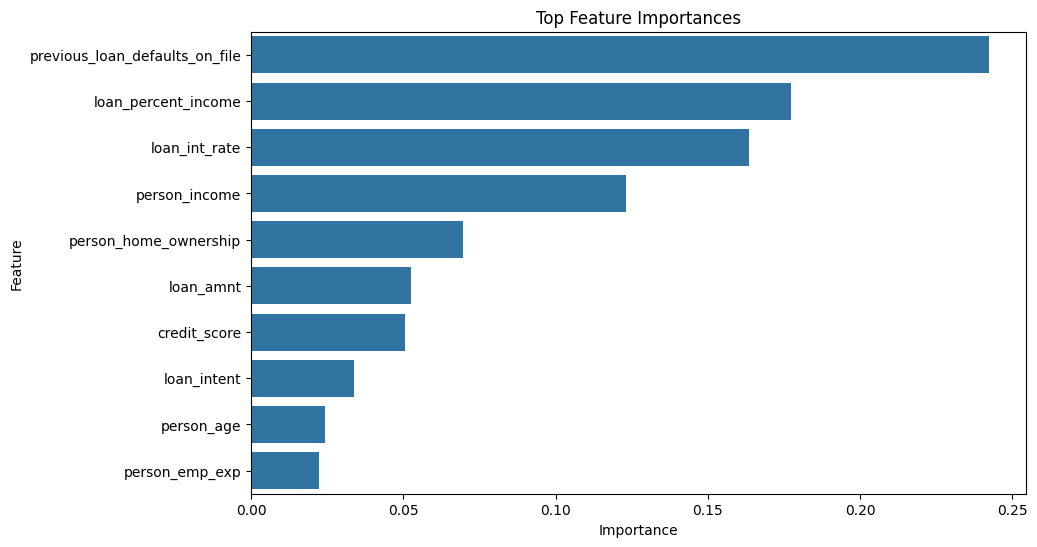

In [38]:
feature_names = X.columns

feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': best_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nTop Features:")
print(feat_imp.head(10))

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feat_imp.head(10))
plt.title("Top Feature Importances")
plt.show()